# 04 · Uplift Modeling
**Churn Detective — Telecom Retention Brief**

**Goal:** Train S-Learner and T-Learner meta-learners to estimate Individual Treatment Effects (ITE). Validate using Qini curve and AUUC. Classify all customers into the four persuadability quadrants. Produce the ranked Persuadable list for the retention team.

**Inputs:** `data/processed/train.parquet`, `data/processed/test.parquet`

**Outputs:**
- `models/uplift_slearner_v1.pkl`  
- `models/uplift_tlearner_v1.pkl`  
- `data/processed/test.parquet` — enriched with `uplift_score`, `uplift_quadrant`  
- `outputs/figures/uplift_qini_curve.png`  
- `outputs/figures/uplift_decile_table.png`  
- `outputs/figures/uplift_four_quadrants.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib

from src.features import prepare_for_lgbm
from src.uplift import (
    build_treatment_variable,
    fit_and_compare_learners,
    classify_four_quadrants,
    uplift_decile_table,
    qini_curve, auuc_score,
)

NAVY  = '#111e35'; TEAL  = '#2dd4bf'
AMBER = '#fbbf24'; ROSE  = '#fb7185'
SLATE = '#94a3b8'; INDIGO = '#818cf8'

plt.rcParams.update({
    'figure.facecolor': NAVY, 'axes.facecolor': NAVY,
    'axes.edgecolor': '#1a2d4e', 'axes.labelcolor': SLATE,
    'xtick.color': SLATE, 'ytick.color': SLATE,
    'text.color': '#cbd5e1', 'grid.color': '#1a2d4e',
    'grid.linestyle': '--', 'grid.alpha': 0.4,
    'figure.dpi': 130,
})

FIG_DIR   = '../outputs/figures'
MODEL_DIR = '../models'
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_STATE = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data & Build Treatment Variable

In [2]:
train_df = pd.read_parquet('../data/processed/train.parquet')
test_df  = pd.read_parquet('../data/processed/test.parquet')

y_train = train_df['churned']
y_test  = test_df['churned']

# ── Treatment variable ────────────────────────────────────────────────
# Strategy: plan_changes_6mo > 0 = customer engaged with a plan change
# (proxy for having received/responded to a retention-like offer).
# See uplift.py docstring for full assumption documentation.
T_train = build_treatment_variable(train_df, strategy='plan_changes')
T_test  = build_treatment_variable(test_df,  strategy='plan_changes')

print(f'\nTrain treatment rate : {T_train.mean():.3f}')
print(f'Test  treatment rate : {T_test.mean():.3f}')

[uplift] Treatment strategy: plan_changes_6mo > 0  → 2,225 treated (39.7% of population)
  ⚠  ASSUMPTION: plan changes proxy engagement with retention offer.
     Validate with A/B test before production deployment.
[uplift] Treatment strategy: plan_changes_6mo > 0  → 540 treated (38.6% of population)
  ⚠  ASSUMPTION: plan changes proxy engagement with retention offer.
     Validate with A/B test before production deployment.

Train treatment rate : 0.397
Test  treatment rate : 0.386


In [3]:
# ── Feature matrices (LightGBM path) ─────────────────────────────────
X_train = prepare_for_lgbm(train_df)
X_test  = prepare_for_lgbm(test_df)

# Drop non-feature columns added by downstream notebooks
_drop = [c for c in ['segment_label', 'churn_proba', 'uplift_score', 'ite_s', 'ite_t', 'uplift_quadrant', 'monthly_charges_bin']
        if c in X_train.columns]
X_train = X_train.drop(columns=_drop)
X_test  = X_test.drop(columns=_drop)

# Sanity check: treatment vs churn cross-tab
cross = pd.crosstab(T_train, y_train, margins=True)
cross.index   = ['Control (T=0)', 'Treatment (T=1)', 'Total']
cross.columns = ['Retained', 'Churned', 'Total']
print('\nTreatment × Outcome cross-tabulation (train):')
print(cross)


Treatment × Outcome cross-tabulation (train):
                 Retained  Churned  Total
Control (T=0)        2131     1244   3375
Treatment (T=1)      1444      781   2225
Total                3575     2025   5600


## 2. Fit S-Learner & T-Learner, Compare AUUC

In [4]:
results = fit_and_compare_learners(
    X_train, X_test,
    T_train, T_test,
    y_train, y_test,
)

ite_s = results['ite_s_test']   # S-Learner ITE
ite_t = results['ite_t_test']   # T-Learner ITE
churn_proba = results['churn_proba_test']

[uplift] Fitting S-Learner…


[uplift] Fitting T-Learner…



[uplift] AUUC — S-Learner: 0.1550 | T-Learner: 0.0316
[uplift] ITE rank correlation (Spearman): 0.242
         ⚠  Low agreement. Investigate; consider X-Learner or DR-Learner.


## 3. Qini Curve Comparison

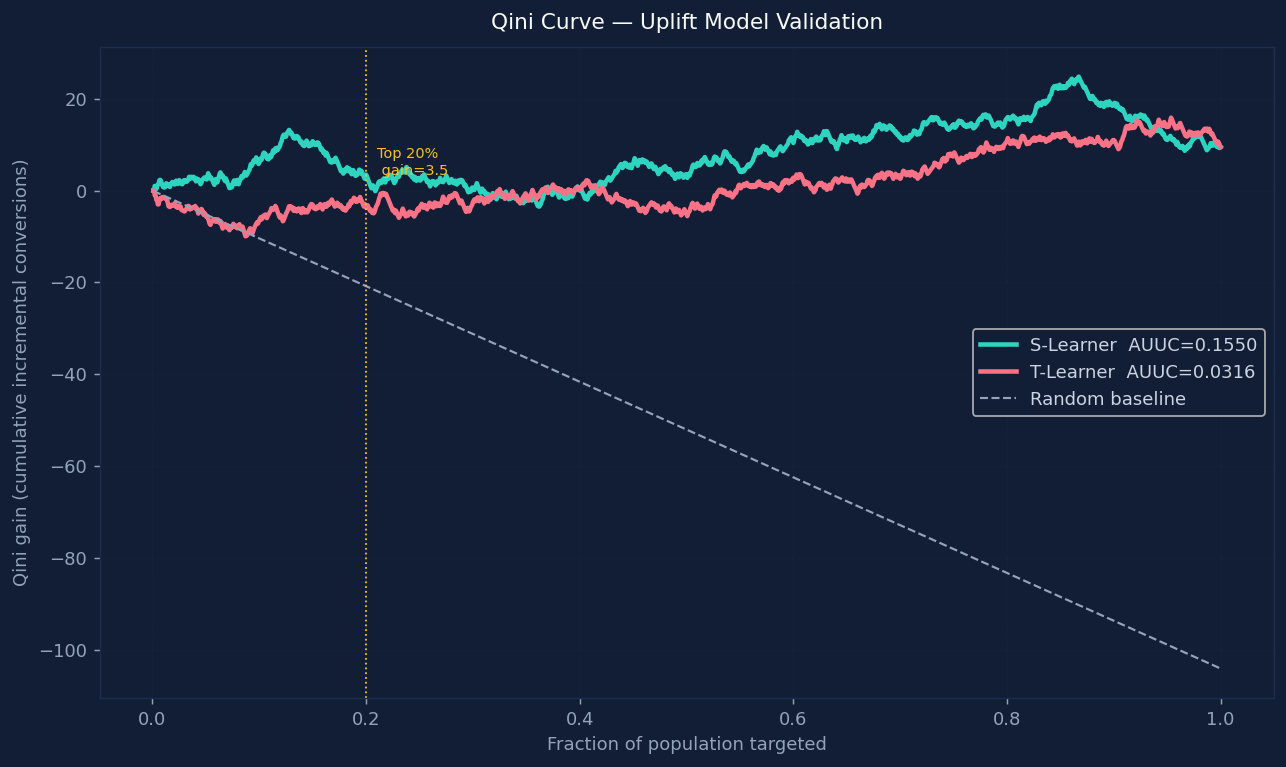

ITE rank correlation (S vs T): 0.2425
→ Using S-Learner as primary ranking signal.


In [5]:
qini_s = results['qini_s']
qini_t = results['qini_t']

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

ax.plot(qini_s['fraction_targeted'], qini_s['qini_gain'],
        color=TEAL,  lw=2.5, label=f'S-Learner  AUUC={results["auuc_s"]:.4f}')
ax.plot(qini_t['fraction_targeted'], qini_t['qini_gain'],
        color=ROSE,  lw=2.5, label=f'T-Learner  AUUC={results["auuc_t"]:.4f}')
ax.plot(qini_s['fraction_targeted'], qini_s['random_gain'],
        color=SLATE, lw=1.2, linestyle='--', label='Random baseline')

ax.set_xlabel('Fraction of population targeted')
ax.set_ylabel('Qini gain (cumulative incremental conversions)')
ax.set_title('Qini Curve — Uplift Model Validation',
             color='#f8fafc', fontsize=12, pad=10)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Annotate: target top 20%
frac_20 = qini_s.iloc[(qini_s['fraction_targeted'] - 0.20).abs().idxmin()]
ax.axvline(0.20, color=AMBER, lw=1, linestyle=':')
ax.text(0.21, frac_20['qini_gain'],
        f'Top 20%\n gain={frac_20["qini_gain"]:.1f}',
        color=AMBER, fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uplift_qini_curve.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()

print(f'ITE rank correlation (S vs T): {results["ite_rank_correlation"]:.4f}')
print('→ Using S-Learner as primary ranking signal.' if results['auuc_s'] >= results['auuc_t']
      else '→ Using T-Learner as primary ranking signal.')

primary_ite = ite_s if results['auuc_s'] >= results['auuc_t'] else ite_t

## 4. Uplift Decile Table

In [6]:
decile_df = uplift_decile_table(y_test, primary_ite, T_test, n_deciles=10)
print('=== Uplift Decile Table ===')
print(decile_df.to_string(index=False))

=== Uplift Decile Table ===
 decile  n_total  n_treated  n_control  outcome_rate_treated  outcome_rate_control  uplift_rate  cumulative_uplift_rate  pct_of_total_uplift
      1      140         63         77                0.4603                0.3636       0.0967                  0.0967                108.2
      2      140         55         85                0.4364                0.4706      -0.0342                  0.0625                -38.3
      3      140         55         85                0.3273                0.3882      -0.0610                  0.0015                -68.2
      4      140         53         87                0.3396                0.3448      -0.0052                 -0.0037                 -5.8
      5      140         57         83                0.3509                0.3012       0.0497                  0.0460                 55.6
      6      301        106        195                0.4151                0.3333       0.0818                  0.1278       

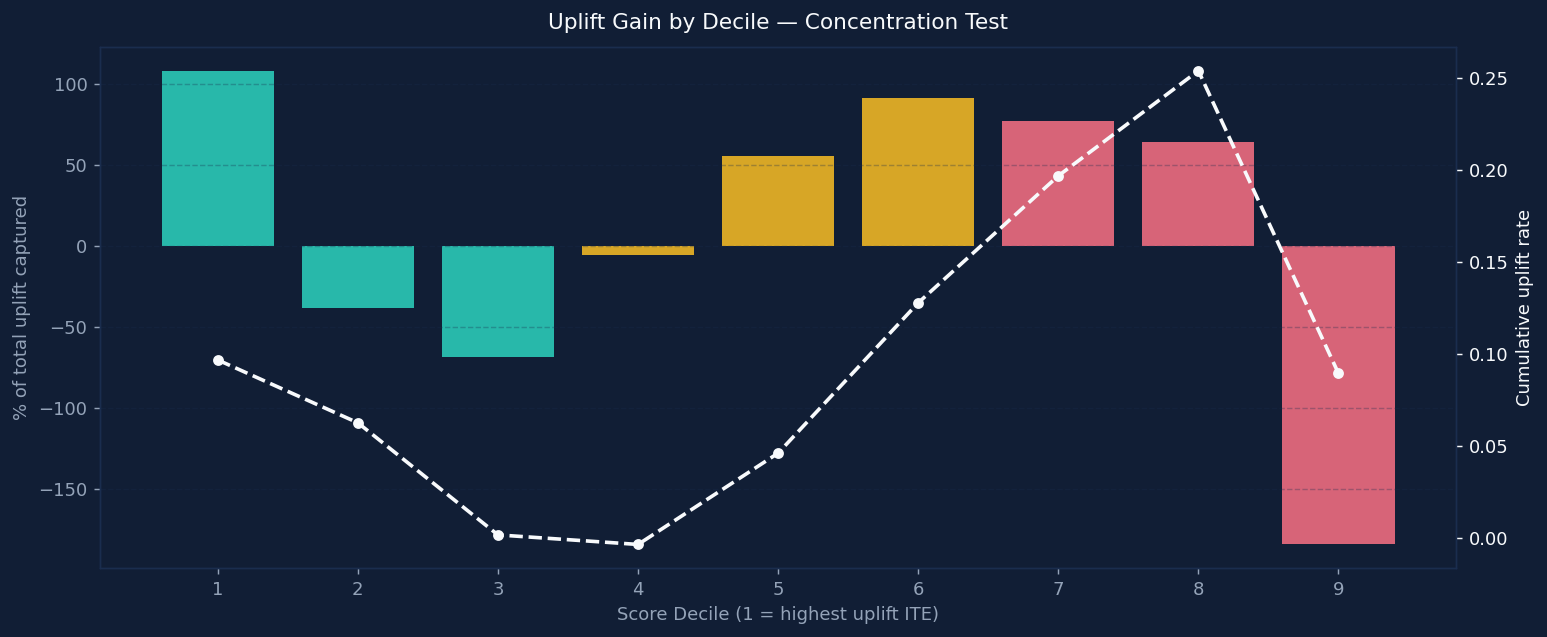

In [7]:
# ── Decile bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

colors = [TEAL if d <= 3 else AMBER if d <= 6 else ROSE
          for d in decile_df['decile']]
bars = ax.bar(decile_df['decile'].astype(str),
              decile_df['pct_of_total_uplift'],
              color=colors, alpha=0.85, edgecolor='none')

# Cumulative line on secondary axis
ax2 = ax.twinx()
ax2.plot(decile_df['decile'].astype(str),
         decile_df['cumulative_uplift_rate'],
         'o--', color='#f8fafc', lw=2, ms=5)
ax2.set_ylabel('Cumulative uplift rate', color='#f8fafc')
ax2.tick_params(colors='#f8fafc')
ax2.set_facecolor(NAVY)

ax.set_xlabel('Score Decile (1 = highest uplift ITE)')
ax.set_ylabel('% of total uplift captured')
ax.set_title('Uplift Gain by Decile — Concentration Test',
             color='#f8fafc', fontsize=12, pad=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uplift_decile_table.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()

## 5. Four-Quadrant Classification

In [8]:
# Threshold for ITE: 0 (positive ITE = offer helps)
# Threshold for churn: use optimal business threshold from notebook 02
CHURN_THRESHOLD = 0.40  # update with optimal_threshold from notebook 02
ITE_THRESHOLD   = 0.0

quadrants = classify_four_quadrants(
    churn_proba     = churn_proba,
    ite_scores      = primary_ite,
    churn_threshold = CHURN_THRESHOLD,
    ite_threshold   = ITE_THRESHOLD,
)

quad_counts = quadrants.value_counts()
print('=== Four-Quadrant Distribution ===')
for quad, n in quad_counts.items():
    pct = n / len(quadrants) * 100
    print(f'  {quad:<20} : {n:>4}  ({pct:.1f}%)')

=== Four-Quadrant Distribution ===
  Persuadable          :  433  (30.9%)
  Sure Saver           :  369  (26.4%)
  Sleeping Dog         :  303  (21.6%)
  Lost Cause           :  295  (21.1%)


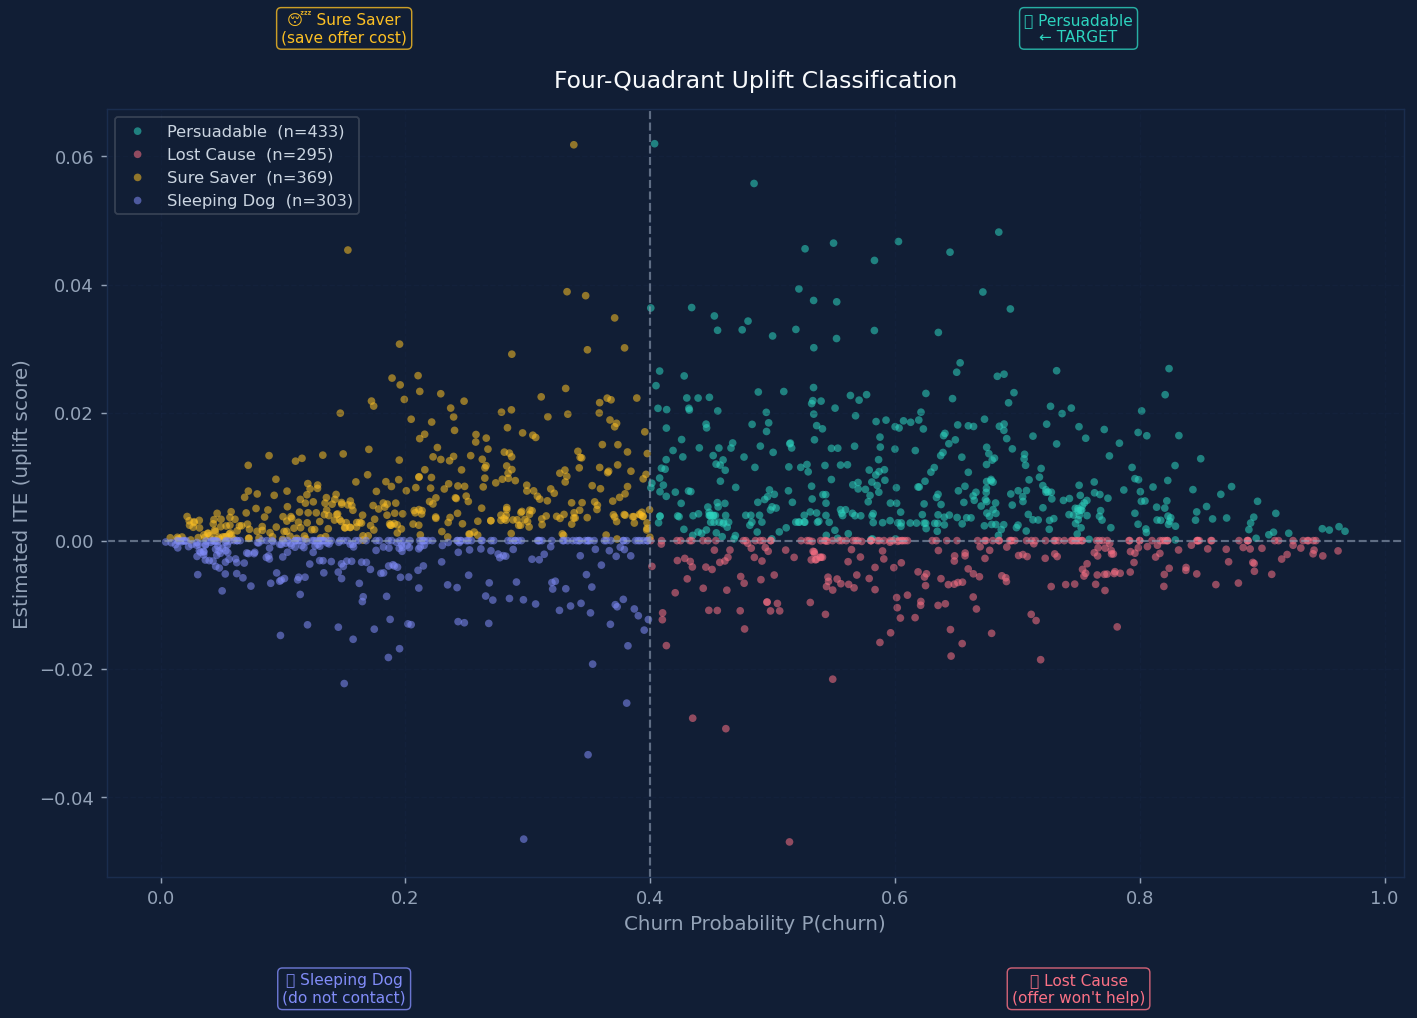

Saved uplift_four_quadrants.png


In [9]:
# ── Four-quadrant scatter ─────────────────────────────────────────────
quad_colors = {
    'Persuadable' : TEAL,
    'Lost Cause'  : ROSE,
    'Sure Saver'  : AMBER,
    'Sleeping Dog': INDIGO,
}

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

for quad, color in quad_colors.items():
    mask = quadrants == quad
    ax.scatter(
        churn_proba[mask], primary_ite[mask],
        c=color, alpha=0.55, s=18,
        label=f'{quad}  (n={mask.sum():,})', edgecolors='none'
    )

ax.axvline(CHURN_THRESHOLD, color=SLATE, lw=1.2, linestyle='--', alpha=0.6)
ax.axhline(ITE_THRESHOLD,   color=SLATE, lw=1.2, linestyle='--', alpha=0.6)

# Quadrant labels
label_positions = [
    (0.75, 0.08, '🎯 Persuadable\n← TARGET', TEAL),
    (0.75, -0.07, '💀 Lost Cause\n(offer won\'t help)', ROSE),
    (0.15, 0.08, '😴 Sure Saver\n(save offer cost)', AMBER),
    (0.15, -0.07, '🐕 Sleeping Dog\n(do not contact)', INDIGO),
]
for x, y, text, color in label_positions:
    ax.text(x, y, text, color=color, fontsize=8.5,
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=NAVY,
                      edgecolor=color, alpha=0.8, lw=0.8))

ax.set_xlabel('Churn Probability P(churn)', fontsize=11)
ax.set_ylabel('Estimated ITE (uplift score)', fontsize=11)
ax.set_title('Four-Quadrant Uplift Classification',
             color='#f8fafc', fontsize=13, pad=12)
ax.legend(fontsize=9, framealpha=0.2, loc='upper left')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/uplift_four_quadrants.png', bbox_inches='tight',
            dpi=130, facecolor=NAVY)
plt.show()
print('Saved uplift_four_quadrants.png')

## 6. Save Artifacts & Enrich Test Set

In [10]:
# ── Save uplift models ────────────────────────────────────────────────
joblib.dump(results['s_learner'], f'{MODEL_DIR}/uplift_slearner_v1.pkl')
joblib.dump(results['t_learner'], f'{MODEL_DIR}/uplift_tlearner_v1.pkl')

# ── Enrich test parquet ───────────────────────────────────────────────
test_df['uplift_score']    = primary_ite
test_df['ite_s']           = ite_s
test_df['ite_t']           = ite_t
test_df['uplift_quadrant'] = quadrants.values

test_df.to_parquet('../data/processed/test.parquet', index=False)

print('Saved:')
print('  models/uplift_slearner_v1.pkl')
print('  models/uplift_tlearner_v1.pkl')
print('  data/processed/test.parquet  (+ uplift_score, uplift_quadrant)')

persuadables = test_df[test_df['uplift_quadrant'] == 'Persuadable']
print(f'\nPersuadable customers in test set: {len(persuadables):,}')
print(f'Monthly revenue at risk (Persuadables): ${persuadables["monthly_charges"].sum():,.0f}')
print('\n✓ Notebook 04 complete. Proceed to 05_cost_threshold.ipynb')

Saved:
  models/uplift_slearner_v1.pkl
  models/uplift_tlearner_v1.pkl
  data/processed/test.parquet  (+ uplift_score, uplift_quadrant)

Persuadable customers in test set: 433
Monthly revenue at risk (Persuadables): $30,847

✓ Notebook 04 complete. Proceed to 05_cost_threshold.ipynb
